In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### K = 3
File imports

In [3]:
q_matrix_path = '../data/structure/q_matrix_3'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'



In [4]:
q_matrix_df = pd.read_csv(q_matrix_path, index_col=0)
bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

q_matrix_df = pd.merge(q_matrix_df, bam, left_index=True, right_index=True)
q_matrix_df.head()

,prop_missing,prop_1,prop_2,prop_3,Sample_ID
0,0.01,0.690,0.012,0.298,ucin001
1,0.02,0.042,0.009,0.949,ucin002
2,0.03,0.042,0.002,0.956,ucin003
3,0.02,0.668,0.002,0.330,ucin004conc
4,0.00,0.123,0.005,0.872,ucin005


In [5]:
meta_df = pd.read_csv(meta_path)
meta_df.head()

,Unnamed: 0.1,Unnamed: 0,Sample_ID,latitude,longitude,is_replicate,replicate,library,barcode,id,POP
0,0,0,ucin001,38.908602,-92.477809,False,NaN,14,ACCA,ucin001,MO
1,1,1,ucin002,37.915594,-90.525565,False,NaN,15,ACCA,ucin002,MO
2,2,2,ucin003,37.824835,-92.207022,False,NaN,16,ACCA,ucin003,MO
3,3,3,ucin004conc,38.935162,-91.465437,False,NaN,9,AGTG,ucin004conc,MO
4,4,4,ucin005,37.800541,-90.511032,False,NaN,10,AGTG,ucin005,MO


In [6]:
q_matrix_df_merged = pd.merge(left=q_matrix_df, right=meta_df[['Sample_ID','POP']], left_on='Sample_ID', right_on='Sample_ID').iloc[:, 1:]
q_matrix_df_merged.head()

,prop_1,prop_2,prop_3,Sample_ID,POP
0,0.690,0.012,0.298,ucin001,MO
1,0.042,0.009,0.949,ucin002,MO
2,0.042,0.002,0.956,ucin003,MO
3,0.668,0.002,0.330,ucin004conc,MO
4,0.123,0.005,0.872,ucin005,MO


['MO' 'KY_TN' 'SC_NC' 'MN_WI_ND' 'IA_NE' 'KS_OK' 'IL_IN' 'MS' 'AR' 'MI'
 'LA' 'OH_WV'] POP
MO          48
KY_TN       59
SC_NC        9
MN_WI_ND    26
IA_NE       11
KS_OK       12
IL_IN       13
MS          15
AR          29
MI           5
LA           6
OH_WV       11
Name: count, dtype: int64


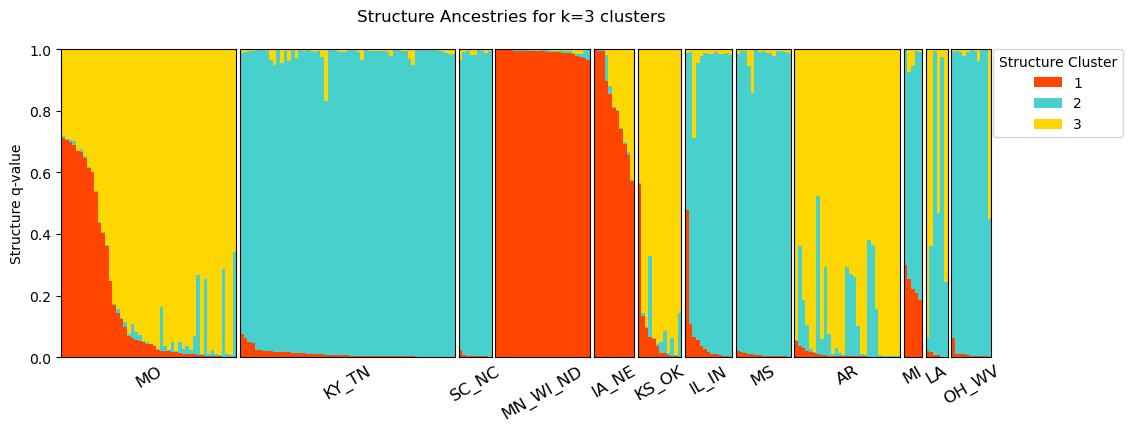

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib import font_manager



# Get population sizes
pop_counts = q_matrix_df_merged["POP"].value_counts(sort=False)
pops = q_matrix_df_merged.POP.unique()

print(pops, pop_counts)

# Figure and GridSpec
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(
    1, len(pops),
    width_ratios=[pop_counts[pop] for pop in pops],
    wspace=0.05  # remove horizontal padding
)

# First axis
first_ax = fig.add_subplot(gs[0])
axes = [first_ax] + [fig.add_subplot(gs[i], sharey=first_ax) for i in range(1, len(pops))]

for i, (ax, pop) in enumerate(zip(axes, pops)):
    subset = q_matrix_df_merged[q_matrix_df_merged.POP == pop].copy()
    subset['max_prob'] = subset.iloc[:, :3].max(axis=1)
    subset = subset.sort_values(by=['prop_1','prop_2','prop_3'], ascending=[False, False, False]).reset_index(drop=True)

    # Get columns you want to plot
    props = [c for c in subset.columns if c.startswith('prop_')]
    x = np.arange(len(subset))

    bottom = np.zeros(len(subset))
    colors = ['orangered', 'mediumturquoise', 'gold']
    props = [c for c in subset.columns if c.startswith('prop_')]

    for col, color in zip(props, colors):
        # Only add label once (for the first subplot)
        label = col.split('_')[-1] if i == 11 else None
        ax.bar(x, subset[col].values, bottom=bottom, color=color, width=1.0, label=label)
        bottom += subset[col].values



    ax.set_xlabel(f"{pop}", rotation=30, fontsize=12)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.5, len(subset)-0.5])

    # Only keep y-axis for first subplot
    if i > 0:
        ax.set_ylabel("")
        ax.get_yaxis().set_visible(False)

axes[0].set_ylabel('Structure q-value')
    # Add legend only to the first subplot

axes[-1].legend(
title="Structure Cluster",
bbox_to_anchor=(1.05, 1),   # 5% to the right of the last axis, vertically centered
loc="upper left",            # anchor the left side of the legend box
borderaxespad=0
)

fig.suptitle('Structure Ancestries for k=3 clusters')

plt.savefig('../structure_k3.pdf', dpi=300)
plt.show()


# k = 2

['MN_WI_ND', 'IA_NE', 'MO', 'MI', 'KS_OK', 'IL_IN', 'AR', 'LA', 'OH_WV', 'KY_TN', 'MS', 'SC_NC'] POP
MN_WI_ND    26
IA_NE       11
MO          48
MI           5
KS_OK       12
IL_IN       13
AR          29
LA           6
OH_WV       11
KY_TN       59
MS          15
SC_NC        9
Name: count, dtype: int64


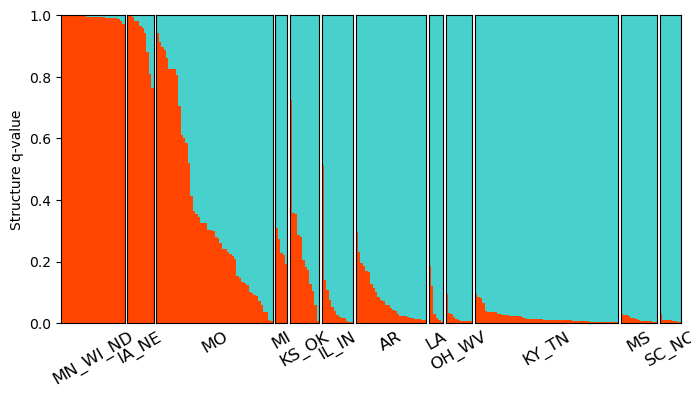

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib import font_manager

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 # Also recommended for PostScript output



q_matrix_path = '../data/structure/q_matrix_2'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'

q_matrix_df = pd.read_csv(q_matrix_path, index_col=0)
bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

q_matrix_df = pd.merge(q_matrix_df, bam, left_index=True, right_index=True)
q_matrix_df.head()

meta_df = pd.read_csv(meta_path)
meta_df.head()

q_matrix_df_merged = pd.merge(left=q_matrix_df, right=meta_df[['Sample_ID','POP']], left_on='Sample_ID', right_on='Sample_ID').iloc[:, 1:]
q_matrix_df_merged.head()

# Specify the path to your Arial.ttf file
# font_path = '../data/fonts/Arial.ttf'

# # Add the font to Matplotlib
# font_manager.fontManager.addfont('../data/fonts/Arial.ttf')
# font_manager.fontManager.addfont('../data/fonts/Arial_Bold.ttf')
# font_manager.fontManager.addfont('../data/fonts/Arial_Bold_Italic.ttf')
                                 

# # Set the font family globally
# plt.rcParams['font.family'] = 'Arial'


# Sort populations by mean prop_1
pop_order = (
    q_matrix_df_merged.groupby("POP")["prop_1"]
    .mean()
    .sort_values(ascending=False)
    .index
)

pops = pop_order.tolist()
pop_counts = q_matrix_df_merged["POP"].value_counts()[pops]


print(pops, pop_counts)

# Figure and GridSpec
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(
    1, len(pops),
    width_ratios=[pop_counts[pop] for pop in pops],
    wspace=0.05  # remove horizontal padding
)

# First axis
first_ax = fig.add_subplot(gs[0])
axes = [first_ax] + [fig.add_subplot(gs[i], sharey=first_ax) for i in range(1, len(pops))]

for i, (ax, pop) in enumerate(zip(axes, pops)):
    subset = q_matrix_df_merged[q_matrix_df_merged.POP == pop].copy()
    subset['max_prob'] = subset.iloc[:, :2].max(axis=1)
    subset = subset.sort_values(by=['prop_1','prop_2'], ascending=[False, False]).reset_index(drop=True)

    # Get columns you want to plot
    props = [c for c in subset.columns if c.startswith('prop_')]
    x = np.arange(len(subset))

    bottom = np.zeros(len(subset))
    colors = ['orangered', 'mediumturquoise', 'gold']
    props = [c for c in subset.columns if c.startswith('prop_')]

    for col, color in zip(props, colors):
        # Only add label once (for the first subplot)
        label = col.split('_')[-1] if i == 11 else None
        ax.bar(x, subset[col].values, bottom=bottom, color=color, width=1.0, label=label)
        bottom += subset[col].values



    ax.set_xlabel(f"{pop}", rotation=30, fontsize=12)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.5, len(subset)-0.5])

    # Only keep y-axis for first subplot
    if i > 0:
        ax.set_ylabel("")
        ax.get_yaxis().set_visible(False)

axes[0].set_ylabel('Structure q-value')
    # Add legend only to the first subplot


import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


plt.savefig('../structure_k2.pdf', dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=True)
plt.show()


['MN_WI_ND', 'IA_NE', 'MO', 'MI', 'KS_OK', 'IL_IN', 'AR', 'LA', 'OH_WV', 'KY_TN', 'MS', 'SC_NC'] POP
MN_WI_ND    26
IA_NE       11
MO          48
MI           5
KS_OK       12
IL_IN       13
AR          29
LA           6
OH_WV       11
KY_TN       59
MS          15
SC_NC        9
Name: count, dtype: int64


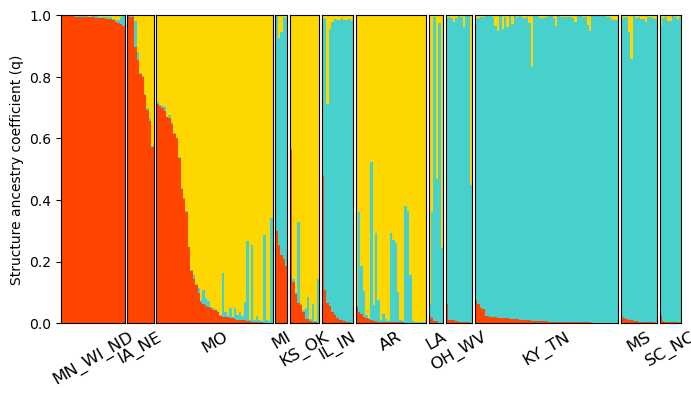

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib import font_manager

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 # Also recommended for PostScript output



q_matrix_path = '../data/structure/q_matrix_3'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'

q_matrix_df = pd.read_csv(q_matrix_path, index_col=0)
bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

q_matrix_df = pd.merge(q_matrix_df, bam, left_index=True, right_index=True)
q_matrix_df.head()

meta_df = pd.read_csv(meta_path)
meta_df.head()

q_matrix_df_merged = pd.merge(left=q_matrix_df, right=meta_df[['Sample_ID','POP']], left_on='Sample_ID', right_on='Sample_ID').iloc[:, 1:]
q_matrix_df_merged.head()

# q_matrix_df_merged[['POP']] = q_matrix_df_merged[['POP']].apply(lambda x: x.replace('SC_NC','NC'))
# q_matrix_df_merged[['POP']] = q_matrix_df_merged[['POP']].apply(lambda x: x.replace('OH_WV','WV'))
# q_matrix_df_merged[['POP']] = q_matrix_df_merged[['POP']].apply(lambda x: x.replace('_',', '))

# Specify the path to your Arial.ttf file
# font_path = '../data/fonts/Arial.ttf'

# # Add the font to Matplotlib
# font_manager.fontManager.addfont('../data/fonts/Arial.ttf')
# font_manager.fontManager.addfont('../data/fonts/Arial_Bold.ttf')
# font_manager.fontManager.addfont('../data/fonts/Arial_Bold_Italic.ttf')
                                 

# # Set the font family globally
# plt.rcParams['font.family'] = 'Arial'


# Sort populations by mean prop_1
# pop_order = (
#     q_matrix_df_merged.groupby("POP")["prop_1"]
#     .mean()
#     .sort_values(ascending=False)
#     .index
# )

pops = pop_order.tolist()
pop_counts = q_matrix_df_merged["POP"].value_counts()[pops]


print(pops, pop_counts)

# Figure and GridSpec
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(
    1, len(pops),
    width_ratios=[pop_counts[pop] for pop in pops],
    wspace=0.05  # remove horizontal padding
)

# First axis
first_ax = fig.add_subplot(gs[0])
axes = [first_ax] + [fig.add_subplot(gs[i], sharey=first_ax) for i in range(1, len(pops))]

for i, (ax, pop) in enumerate(zip(axes, pops)):
    subset = q_matrix_df_merged[q_matrix_df_merged.POP == pop].copy()
    subset['max_prob'] = subset.iloc[:, :3].max(axis=1)
    subset = subset.sort_values(by=['prop_1','prop_2', 'prop_3'], ascending=[False, False, False]).reset_index(drop=True)

    # Get columns you want to plot
    props = [c for c in subset.columns if c.startswith('prop_')]
    x = np.arange(len(subset))

    bottom = np.zeros(len(subset))
    colors = ['orangered', 'mediumturquoise', 'gold']
    props = [c for c in subset.columns if c.startswith('prop_')]

    for col, color in zip(props, colors):
        # Only add label once (for the first subplot)
        label = col.split('_')[-1] if i == 11 else None
        ax.bar(x, subset[col].values, bottom=bottom, color=color, width=1.0, label=label)
        bottom += subset[col].values



    ax.set_xlabel(f"{pop}", rotation=30, fontsize=12)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.5, len(subset)-0.5])

    # Only keep y-axis for first subplot
    if i > 0:
        ax.set_ylabel("")
        ax.get_yaxis().set_visible(False)

axes[0].set_ylabel('Structure ancestry coefficient (q)')
    # Add legend only to the first subplot


import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


plt.savefig('../structure_k3.pdf', dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=True)
plt.show()


k=4

['MN_WI_ND', 'IA_NE', 'MO', 'MI', 'KS_OK', 'IL_IN', 'AR', 'LA', 'OH_WV', 'KY_TN', 'MS', 'SC_NC'] POP
MN_WI_ND    26
IA_NE       11
MO          48
MI           5
KS_OK       12
IL_IN       13
AR          29
LA           6
OH_WV       11
KY_TN       59
MS          15
SC_NC        9
Name: count, dtype: int64


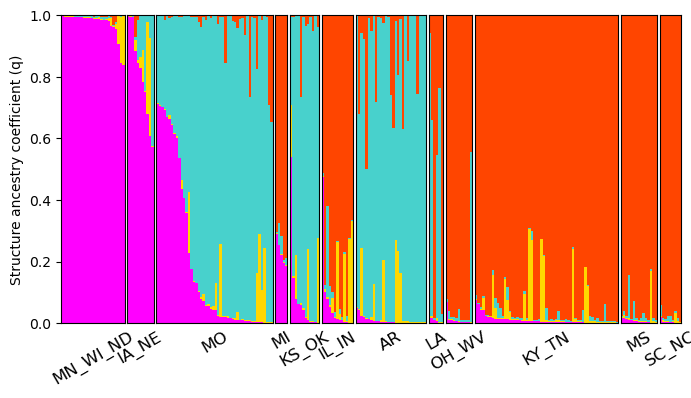

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib import font_manager

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 # Also recommended for PostScript output



q_matrix_path = '../data/structure/q_matrix_4'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'

q_matrix_df = pd.read_csv(q_matrix_path, index_col=0)
bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

q_matrix_df = pd.merge(q_matrix_df, bam, left_index=True, right_index=True)
q_matrix_df.head()

meta_df = pd.read_csv(meta_path)
meta_df.head()

q_matrix_df_merged = pd.merge(left=q_matrix_df, right=meta_df[['Sample_ID','POP']], left_on='Sample_ID', right_on='Sample_ID').iloc[:, 1:]
q_matrix_df_merged.head()

# q_matrix_df_merged[['POP']] = q_matrix_df_merged[['POP']].apply(lambda x: x.replace('SC_NC','NC'))
# q_matrix_df_merged[['POP']] = q_matrix_df_merged[['POP']].apply(lambda x: x.replace('OH_WV','WV'))
# q_matrix_df_merged[['POP']] = q_matrix_df_merged[['POP']].apply(lambda x: x.replace('_',', '))

# Specify the path to your Arial.ttf file
# font_path = '../data/fonts/Arial.ttf'

# # Add the font to Matplotlib
# font_manager.fontManager.addfont('../data/fonts/Arial.ttf')
# font_manager.fontManager.addfont('../data/fonts/Arial_Bold.ttf')
# font_manager.fontManager.addfont('../data/fonts/Arial_Bold_Italic.ttf')
                                 

# # Set the font family globally
# plt.rcParams['font.family'] = 'Arial'


# Sort populations by mean prop_1
# pop_order = (
#     q_matrix_df_merged.groupby("POP")["prop_1"]
#     .mean()
#     .sort_values(ascending=False)
#     .index
# )

pops = pop_order.tolist()
pop_counts = q_matrix_df_merged["POP"].value_counts()[pops]


print(pops, pop_counts)

# Figure and GridSpec
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(
    1, len(pops),
    width_ratios=[pop_counts[pop] for pop in pops],
    wspace=0.05  # remove horizontal padding
)

# First axis
first_ax = fig.add_subplot(gs[0])
axes = [first_ax] + [fig.add_subplot(gs[i], sharey=first_ax) for i in range(1, len(pops))]

for i, (ax, pop) in enumerate(zip(axes, pops)):
    subset = q_matrix_df_merged[q_matrix_df_merged.POP == pop].copy()
    subset['max_prob'] = subset.iloc[:, :4].max(axis=1)
    subset = subset.sort_values(by=['prop_1','prop_2', 'prop_3', 'prop_4'], ascending=[False, False, False, False]).reset_index(drop=True)

    # Get columns you want to plot
    props = [c for c in subset.columns if c.startswith('prop_')]
    x = np.arange(len(subset))

    bottom = np.zeros(len(subset))
    colors = ['magenta',  'gold', 'mediumturquoise','orangered']
    props = [c for c in subset.columns if c.startswith('prop_')]

    for col, color in zip(props, colors):
        # Only add label once (for the first subplot)
        label = col.split('_')[-1] if i == 11 else None
        ax.bar(x, subset[col].values, bottom=bottom, color=color, width=1.0, label=label)
        bottom += subset[col].values



    ax.set_xlabel(f"{pop}", rotation=30, fontsize=12)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.5, len(subset)-0.5])

    # Only keep y-axis for first subplot
    if i > 0:
        ax.set_ylabel("")
        ax.get_yaxis().set_visible(False)

axes[0].set_ylabel('Structure ancestry coefficient (q)')
    # Add legend only to the first subplot


import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


plt.savefig('../structure_k4.pdf', dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=True)
plt.show()
